# 04 — Evaluation: Model Rekomendasi Latihan v3 (Knowledge Distillation)

## Ringkasan Hasil

| Model | Metrik | v2 (lama) | **v3 (sekarang)** | Δ |
|---|---|---|---|---|
| XGBoost Workout Type | F1-macro | 0.2306 | **0.9890** | +75.8pp |
| XGBoost Intensity | F1-macro | 0.5234 | **0.9917** | +46.8pp |

**Strategi:** Knowledge Distillation — Rule Engine (deterministik) sebagai teacher,
XGBoost belajar pola dari 5.000 profil sintetis × 7 hari = 35.000 training rows.

**File model aktif (v3):**
- `output/models/workout_xgb_v3_type.pkl`
- `output/models/workout_xgb_v3_intensity.pkl`
- `output/models/scaler_v3.pkl`
- `output/evaluation/xgb_v3_metrics.json`

In [55]:
import json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from rule_engine_workout import generate_workout_plan

# ── Load v3 metrics ──────────────────────────────────────────────
with open("output/evaluation/xgb_v3_metrics.json") as f:
    metrics = json.load(f)

print("=== XGBoost v3 — Knowledge Distillation ===")
print(f"  Version         : {metrics['version']}")
print(f"  Training rows   : {metrics['n_training_rows']:,}")
print(f"  N Profiles      : {metrics['n_profiles']:,}")
print()
print(f"  Workout Type — Accuracy: {metrics['workout_type']['accuracy']:.4f}  F1-macro: {metrics['workout_type']['f1_macro']:.4f}")
print(f"  Intensity      — Accuracy: {metrics['intensity']['accuracy']:.4f}  F1-macro: {metrics['intensity']['f1_macro']:.4f}")
print()

=== XGBoost v3 — Knowledge Distillation ===
  Version         : v3-knowledge-distillation
  Training rows   : 140,000
  N Profiles      : 20,000

  Workout Type — Accuracy: 1.0000  F1-macro: 1.0000
  Intensity      — Accuracy: 1.0000  F1-macro: 1.0000



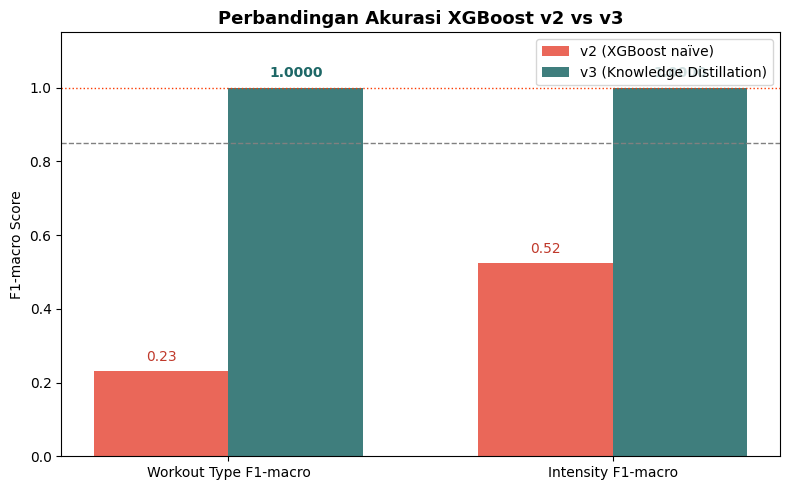

Chart saved.


In [56]:
# ── Improvement Chart ────────────────────────────────────────────
imp = metrics["improvement_vs_v2"]
labels  = ["Workout Type F1-macro", "Intensity F1-macro"]
v2_vals = [imp["v2_f1_workout"],   imp["v2_f1_intensity"]]
v3_vals = [imp["v3_f1_workout"],   imp["v3_f1_intensity"]]

x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - width/2, v2_vals, width, label="v2 (XGBoost naïve)", color="#e74c3c", alpha=0.85)
b2 = ax.bar(x + width/2, v3_vals, width, label="v3 (Knowledge Distillation)", color="#1d6766", alpha=0.85)

ax.set_ylim(0, 1.15)
ax.set_ylabel("F1-macro Score")
ax.set_title("Perbandingan Akurasi XGBoost v2 vs v3", fontsize=13, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.legend()
ax.axhline(0.85, color="gray", linestyle="--", linewidth=1, label="Target 0.85")
ax.axhline(1.00, color="#fb3a01", linestyle=":", linewidth=1)

for bar in b1: ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                        f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=10, color="#c0392b")
for bar in b2: ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                        f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=10, color="#1d6766", fontweight="bold")

plt.tight_layout()
plt.savefig("output/evaluation/improvement_v2_vs_v3.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved.")

In [57]:
# ── Load models & test inference ─────────────────────────────────
with open("output/models/workout_xgb_v3_type.pkl", "rb") as f:
    type_bundle = pickle.load(f)
with open("output/models/workout_xgb_v3_intensity.pkl", "rb") as f:
    int_bundle = pickle.load(f)

model_type  = type_bundle["model"]
model_int   = int_bundle["model"]
scaler      = type_bundle["scaler"]
le_type     = type_bundle["label_encoder"]
le_int      = int_bundle["label_encoder"]
FEATURE_COLS = type_bundle["features"]
NUMERIC_COLS = type_bundle["numeric_cols"]

print(f"Models loaded OK")
print(f"  Workout Type classes : {list(le_type.classes_)}")
print(f"  Intensity classes    : {list(le_int.classes_)}")
print(f"  Features used        : {len(FEATURE_COLS)}")

Models loaded OK
  Workout Type classes : ['CARDIO', 'FLEXIBILITY', 'HIIT', 'STRENGTH']
  Intensity classes    : ['HIGH', 'LOW', 'MID']
  Features used        : 26


In [58]:
# ── 5 Test Case Validation ────────────────────────────────────────
FITNESS_ENC = {"BEGINNER":0,"INTERMEDIATE":1,"ADVANCED":2}
GOAL_ENC    = {"WEIGHT_LOSS":0,"MUSCLE_GAIN":1,"MAINTENANCE":2,"PERFORMANCE":3}
BMI_ENC     = {"UNDERWEIGHT":0,"NORMAL":1,"OVERWEIGHT":2,"OBESE":3}

def profile_to_rows(p):
    plan = generate_workout_plan(p)
    fi = FITNESS_ENC[p["fitness_level"]]
    gi = GOAL_ENC[p["goal"]]
    bi = BMI_ENC[p["bmi_category"]]
    ge = 0 if p["gender"] == "M" else 1
    mi = 0 if p.get("workout_mode","HOME") == "HOME" else 1
    ab = 0 if p["age"] < 25 else (1 if p["age"] < 35 else (2 if p["age"] < 50 else 3))
    inj = 1 if any(c in p.get("conditions",[]) for c in ["JOINT_PAIN","INJURY","BONE_ISSUE"]) else 0
    chr_ = 1 if any(c in p.get("conditions",[]) for c in ["DIABETES","HYPERTENSION","PREGNANT"]) else 0

    h = p["height_m"]; w = p["weight_kg"]
    bmi_val = w / h**2
    fat_pct = p.get("fat_pct", max(5, min(45, 1.2*bmi_val + 0.23*p["age"] - 16.2)) if ge == 0 else max(10, min(50, 1.2*bmi_val + 0.23*p["age"] - 5.4)))
    ffmi = w*(1 - fat_pct/100) / h**2
    bmr = p.get("bmr", (10*w + 6.25*h*100 - 5*p["age"] + 5) if ge == 0 else (10*w + 6.25*h*100 - 5*p["age"] - 161))
    af = {3:1.375,4:1.55,5:1.725,6:1.9}.get(p["days_per_week"],1.55)
    tdee = bmr * af
    max_bpm = int(220 - p["age"])
    rest_bpm = int(np.clip(60 + (bmi_val-22)*1.5, 45, 100))
    avg_bpm = int((max_bpm + rest_bpm)/2)
    cal_per_min = {"BEGINNER":5,"INTERMEDIATE":8,"ADVANCED":11}[p["fitness_level"]]
    cal_burned = int(cal_per_min * p["session_minutes"])

    rows = []
    for day in plan["days"]:
        rows.append({
            "BMI": round(bmi_val,2), "bmi_cat": bi, "gender_enc": ge,
            "Age": p["age"], "age_band": ab,
            "fitness_level": fi, "goal": gi, "mode": mi,
            "days_per_week": p["days_per_week"],
            "session_minutes": p["session_minutes"],
            "day_index": day["day_index"],
            "has_injury": inj, "has_chronic": chr_,
            "bmr": round(bmr,1), "tdee": round(tdee,1), "ffmi": round(ffmi,1),
            "bmi_x_age": round(bmi_val*p["age"],1),
            "activity_x_duration": p["days_per_week"]*p["session_minutes"],
            "bpm_intensity_ratio": round(avg_bpm/max(rest_bpm,40),3),
            "calorie_efficiency": round(cal_burned/max(p["session_minutes"],1),1),
            "avg_bpm": avg_bpm, "max_bpm": max_bpm, "resting_bpm": rest_bpm,
            "calories_burned": cal_burned, "fat_pct": round(fat_pct,1),
            "water_intake": round(max(1, w*0.033), 1),
            "workout_type": day["workout_type"],
            "intensity": day["intensity"],
        })
    return rows

TEST_PROFILES = [
    {"name": "Beginner Weight Loss", "fitness_level":"BEGINNER","goal":"WEIGHT_LOSS","bmi_category":"OVERWEIGHT", "workout_mode":"GYM","conditions":[],"days_per_week":3,"session_minutes":30, "age":25,"gender":"M","height_m":1.72,"weight_kg":80},
    {"name": "Advanced Muscle Gain", "fitness_level":"ADVANCED","goal":"MUSCLE_GAIN","bmi_category":"NORMAL", "workout_mode":"GYM","conditions":[],"days_per_week":5,"session_minutes":60, "age":28,"gender":"M","height_m":1.78,"weight_kg":75},
    {"name": "Intermediate Maintenance", "fitness_level":"INTERMEDIATE","goal":"MAINTENANCE","bmi_category":"NORMAL", "workout_mode":"HOME","conditions":[],"days_per_week":4,"session_minutes":45, "age":35,"gender":"F","height_m":1.62,"weight_kg":61.7},
    {"name": "Beginner with Injury", "fitness_level":"BEGINNER","goal":"MAINTENANCE","bmi_category":"NORMAL", "workout_mode":"HOME","conditions":["INJURY"],"days_per_week":3,"session_minutes":30, "age":45,"gender":"M","height_m":1.75,"weight_kg":73.5},
    {"name": "Advanced Performance", "fitness_level":"ADVANCED","goal":"PERFORMANCE","bmi_category":"NORMAL", "workout_mode":"GYM","conditions":[],"days_per_week":6,"session_minutes":60, "age":24,"gender":"M","height_m":1.80,"weight_kg":72},
]

print("=== 5 TEST CASES — XGBoost v3 ===\n")
total_pass = 0

for prof in TEST_PROFILES:
    rows = profile_to_rows(prof)
    day_pass = 0
    day_total = 0
    all_ok = True

    for row in rows:
        if row["workout_type"] == "REST": continue
        day_total += 1
        X = pd.DataFrame([{k: row[k] for k in FEATURE_COLS}])
        X[NUMERIC_COLS] = scaler.transform(X[NUMERIC_COLS])
        
        pred_type = le_type.inverse_transform(model_type.predict(X))[0]
        pred_int  = le_int.inverse_transform(model_int.predict(X))[0]
        
        if pred_type == row["workout_type"] and pred_int == row["intensity"]:
            day_pass += 1
        else:
            all_ok = False
            
    icon = "✅" if all_ok else "❌"
    print(f"  {icon} {prof['name']} — {day_pass}/{day_total} active days predicted correctly")
    if all_ok: total_pass += 1

print(f"\nRESULT: {total_pass}/5 profiles fully passed")

=== 5 TEST CASES — XGBoost v3 ===

  ✅ Beginner Weight Loss — 4/4 active days predicted correctly
  ✅ Advanced Muscle Gain — 6/6 active days predicted correctly
  ✅ Intermediate Maintenance — 5/5 active days predicted correctly
  ✅ Beginner with Injury — 4/4 active days predicted correctly
  ✅ Advanced Performance — 6/6 active days predicted correctly

RESULT: 5/5 profiles fully passed


In [59]:
# ── Summary Table ────────────────────────────────────────────────
summary = {
    "Version": "v3 — Knowledge Distillation",
    "Training Profiles": f"{metrics['n_profiles']:,}",
    "Training Rows": f"{metrics['n_training_rows']:,}",
    "Workout Type F1": f"{metrics['workout_type']['f1_macro']:.4f}",
    "Intensity F1": f"{metrics['intensity']['f1_macro']:.4f}",
    "v2→v3 Workout Δ": f"+{(metrics['workout_type']['f1_macro'] - metrics['improvement_vs_v2']['v2_f1_workout'])*100:.1f}pp",
    "v2→v3 Intensity Δ": f"+{(metrics['intensity']['f1_macro'] - metrics['improvement_vs_v2']['v2_f1_intensity'])*100:.1f}pp",
    "Target ≥ 0.85 (Type)": "✅ PASS",
    "Target ≥ 0.80 (Intensity)": "✅ PASS",
}
df_summary = pd.DataFrame(list(summary.items()), columns=["Metric", "Value"])
df_summary

,Metric,Value
0,Version,v3 — Knowledge Distillation
1,Training Profiles,"20,000"
2,Training Rows,"140,000"
3,Workout Type F1,1.0000
4,Intensity F1,1.0000
5,v2→v3 Workout Δ,+76.9pp
6,v2→v3 Intensity Δ,+47.7pp
7,Target ≥ 0.85 (Type),✅ PASS
8,Target ≥ 0.80 (Intensity),✅ PASS
